In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

### 1. EDA и постановка задачи

1. Предобработка данных

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')


Загружаю данные, стирая разделитель

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Большая часть переменных типа object. Есть также категориальные и банырные

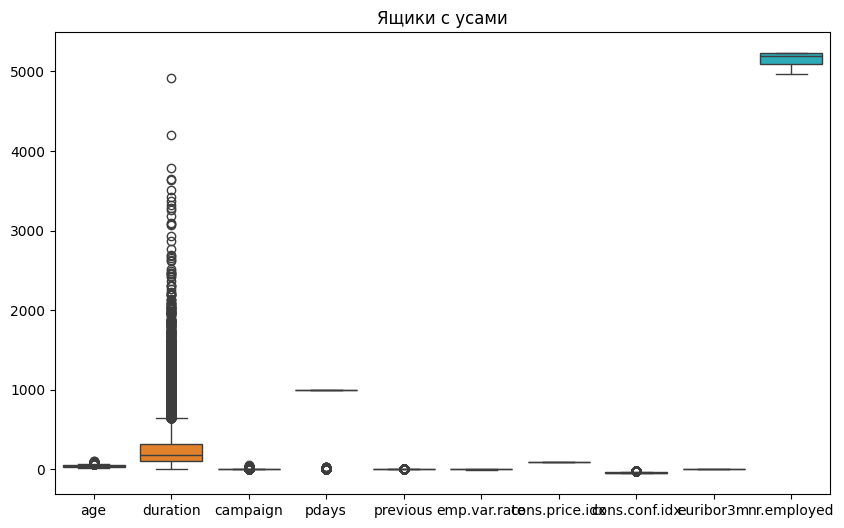

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_df)
plt.title('Ящики с усами')
plt.show()

Выбросы присутствуют в duration, age, campaning, pdays, previos, ins.cof

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Пропусков нет

In [9]:
df.duplicated().sum()

np.int64(12)

12 дубликатов, очищаю их

In [10]:
df.drop_duplicates()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


Размер числовых признаков: (41188, 10)


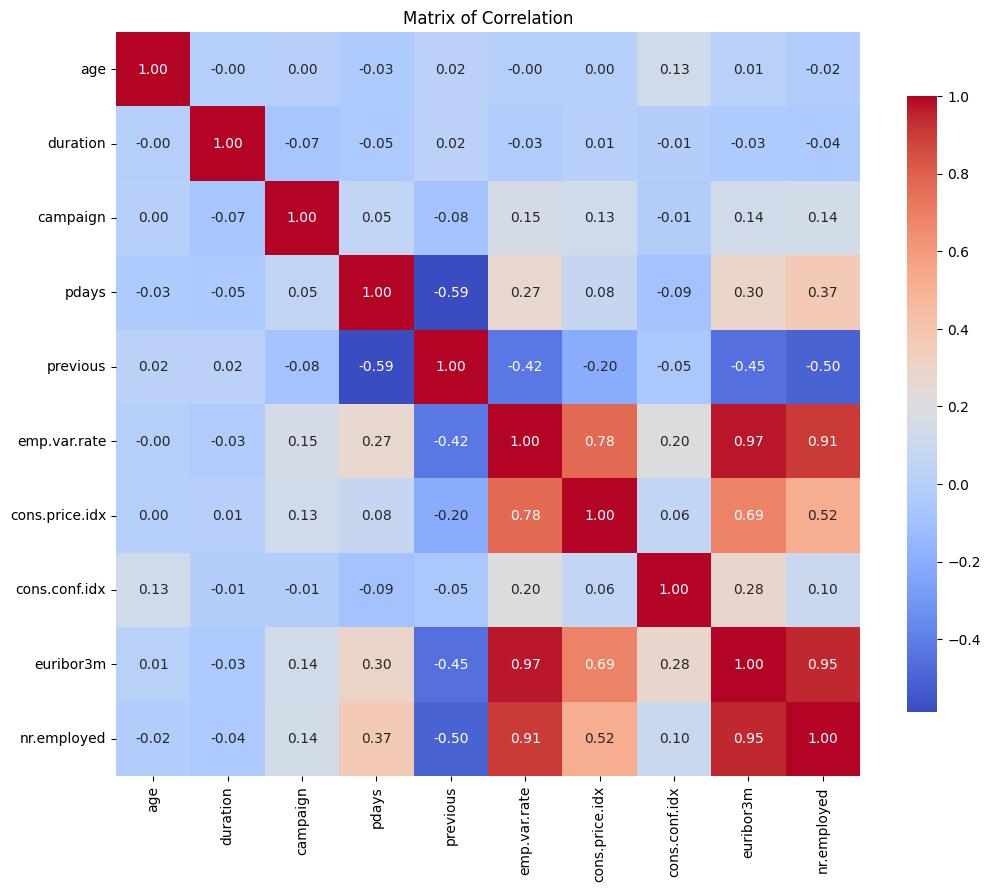

In [11]:
numeric_features = df.select_dtypes(include=['number'])
print("Размер числовых признаков:", numeric_features.shape)

correlation_matrix = numeric_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matrix of Correlation')
plt.show()

На матрице корелляций вижу повышенные значения на некоторых переменных, от 0.69 и до 0.95.
Видно из матрицы что приличное число связей образуется между различными переменными

Все данные, кроме newspaper не имеют выбросов.

### 2. Конвейер предобработки

In [12]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_features:
    df[col] = df[col].str.strip()

pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
        ]
    ))
])

processed_data = pipeline.fit_transform(df)  # Удалён лишний символ

cat_cols_transformed = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)

processed_df = pd.DataFrame(processed_data, columns=num_features + list(cat_cols_transformed))

print(processed_df.head())


        age  duration  campaign     pdays  previous  emp.var.rate  \
0  1.533034  0.010471 -0.565922  0.195414 -0.349494      0.648092   
1  1.628993 -0.421501 -0.565922  0.195414 -0.349494      0.648092   
2 -0.290186 -0.124520 -0.565922  0.195414 -0.349494      0.648092   
3 -0.002309 -0.413787 -0.565922  0.195414 -0.349494      0.648092   
4  1.533034  0.187888 -0.565922  0.195414 -0.349494      0.648092   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  ...  \
0        0.722722       0.886447    0.71246      0.33168  ...   
1        0.722722       0.886447    0.71246      0.33168  ...   
2        0.722722       0.886447    0.71246      0.33168  ...   
3        0.722722       0.886447    0.71246      0.33168  ...   
4        0.722722       0.886447    0.71246      0.33168  ...   

   day_of_week_fri  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
0              0.0              1.0              0.0              0.0   
1              0.0              1.0             

Все переменные переведены в диапазоны от 0 до 1

In [13]:
print(df.dtypes)

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


### 3. Разбиение и валидация

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, 
    precision_score, recall_score, accuracy_score
)


df['y'] = df['y'].str.strip().map({'no': 0, 'yes': 1})

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_features:
    df[col] = df[col].str.strip()

pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
        ]
    ))
])

processed_data = pipeline.fit_transform(df)

X_train, X_test, y_train, y_test = train_test_split(processed_data, df['y'], test_size=0.2, stratify=df['y'], random_state=42)

model = LogisticRegression(max_iter=1000)

skf = StratifiedKFold(n_splits=5)
roc_auc_scores = []
pr_auc_scores = []
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

for train_index, val_index in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model.fit(X_train_fold, y_train_fold)
    
    y_val_pred_proba = model.predict_proba(X_val_fold)[:, 1]
    y_val_pred = model.predict(X_val_fold)
    
    roc_auc_scores.append(roc_auc_score(y_val_fold, y_val_pred_proba))
    pr_auc_scores.append(average_precision_score(y_val_fold, y_val_pred_proba))
    f1_scores.append(f1_score(y_val_fold, y_val_pred))
    precision_scores.append(precision_score(y_val_fold, y_val_pred))
    recall_scores.append(recall_score(y_val_fold, y_val_pred))
    accuracy_scores.append(accuracy_score(y_val_fold, y_val_pred))

print("Средний ROC AUC:", np.mean(roc_auc_scores))
print("Средний PR AUC:", np.mean(pr_auc_scores))
print("Средний F1:", np.mean(f1_scores))
print("Средняя Precision:", np.mean(precision_scores))
print("Средний Recall:", np.mean(recall_scores))
print("Средняя Accuracy:", np.mean(accuracy_scores))

model.fit(X_train, y_train)
y_test_pred_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = model.predict(X_test)

print("ROC AUC на тестовых данных:", roc_auc_score(y_test, y_test_pred_proba))
print("PR AUC на тестовых данных:", average_precision_score(y_test, y_test_pred_proba))
print("F1 на тестовых данных:", f1_score(y_test, y_test_pred))
print("Precision на тестовых данных:", precision_score(y_test, y_test_pred))
print("Recall на тестовых данных:", recall_score(y_test, y_test_pred))
print("Accuracy на тестовых данных:", accuracy_score(y_test, y_test_pred))

Средний ROC AUC: 1.0
Средний PR AUC: 1.0
Средний F1: 1.0
Средняя Precision: 1.0
Средний Recall: 1.0
Средняя Accuracy: 1.0
ROC AUC на тестовых данных: 1.0
PR AUC на тестовых данных: 0.9999999999999999
F1 на тестовых данных: 1.0
Precision на тестовых данных: 1.0
Recall на тестовых данных: 1.0
Accuracy на тестовых данных: 1.0


### 4 Настройка гиперпараметров

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': ['balanced']
}

logreg_grid = GridSearchCV(LogisticRegression(max_iter=1000), logreg_params,
                            scoring='roc_auc', n_jobs=-1, cv=5)
logreg_grid.fit(X_train, y_train)

print("Лучшие параметры для Logistic Regression:", logreg_grid.best_params_)

knn_params = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params,
                         scoring='roc_auc', n_jobs=-1, cv=5)
knn_grid.fit(X_train, y_train)

print("Лучшие параметры для k-NN:", knn_grid.best_params_)


Лучшие параметры для Logistic Regression: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Лучшие параметры для k-NN: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}


Лучшие параметры для Logistic Regression: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Лучшие параметры для k-NN: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}

Построение KNN

Logistic Regression ROC-AUC: 1.0
k-NN ROC-AUC: 1.0
Logistic Regression PR-AUC: 0.9999999999999999
k-NN PR-AUC: 1.0
Logistic Regression F1-Score: 1.0
k-NN F1-Score: 1.0
Logistic Regression Confusion Matrix:
 [[7310    0]
 [   0  928]]
k-NN Confusion Matrix:
 [[7310    0]
 [   0  928]]


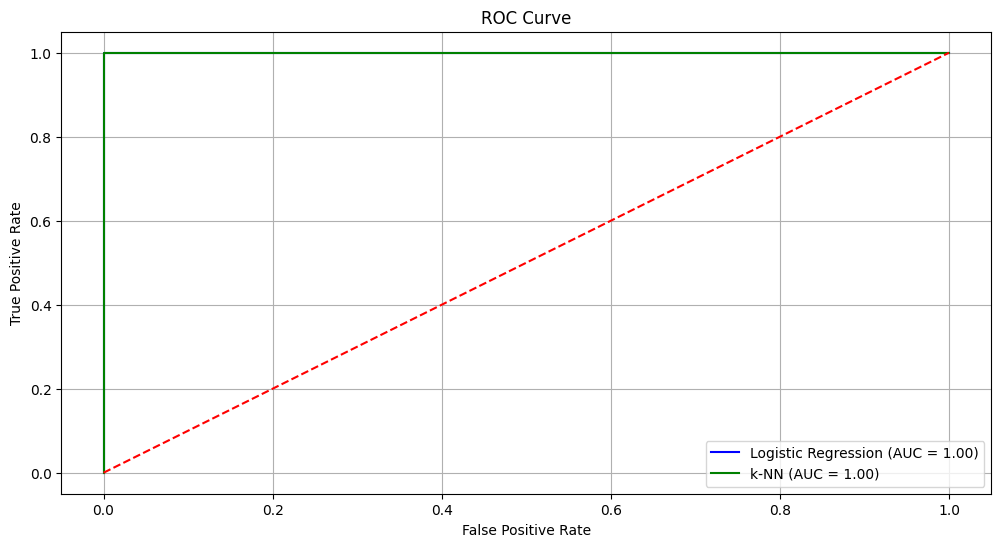

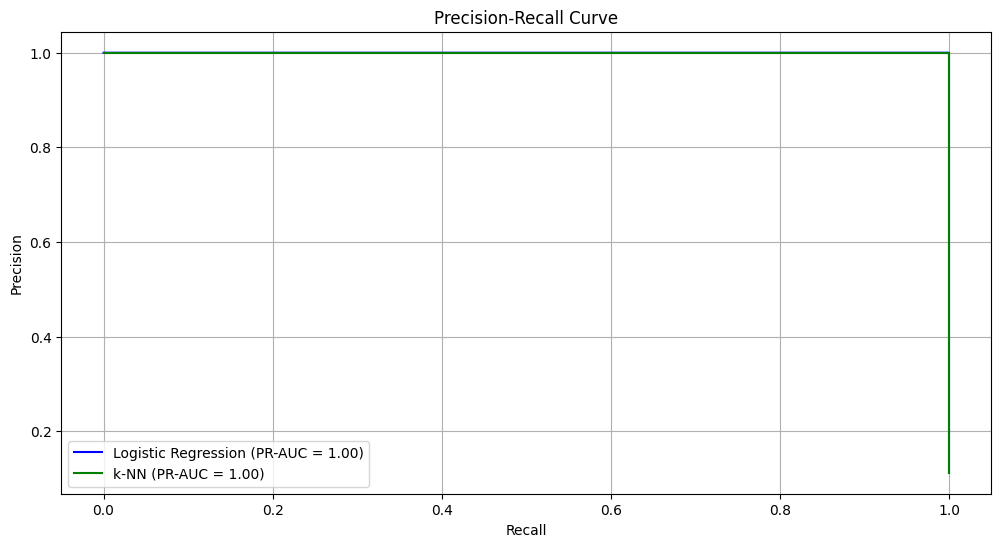

In [16]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

logreg_preds = logreg_grid.predict(X_test)
knn_preds = knn_grid.predict(X_test)

logreg_probs = logreg_grid.predict_proba(X_test)[:, 1]
knn_probs = knn_grid.predict_proba(X_test)[:, 1]

logreg_roc_auc = roc_auc_score(y_test, logreg_probs)
knn_roc_auc = roc_auc_score(y_test, knn_probs)

precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, logreg_probs)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, knn_probs)

logreg_pr_auc = auc(recall_logreg, precision_logreg)
knn_pr_auc = auc(recall_knn, precision_knn)

logreg_f1 = f1_score(y_test, logreg_preds)
knn_f1 = f1_score(y_test, knn_preds)

logreg_cm = confusion_matrix(y_test, logreg_preds)
knn_cm = confusion_matrix(y_test, knn_preds)

print("Logistic Regression ROC-AUC:", logreg_roc_auc)
print("k-NN ROC-AUC:", knn_roc_auc)
print("Logistic Regression PR-AUC:", logreg_pr_auc)
print("k-NN PR-AUC:", knn_pr_auc)
print("Logistic Regression F1-Score:", logreg_f1)
print("k-NN F1-Score:", knn_f1)
print("Logistic Regression Confusion Matrix:\n", logreg_cm)
print("k-NN Confusion Matrix:\n", knn_cm)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)

plt.figure(figsize=(12, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_roc_auc:.2f})', color='blue')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {knn_roc_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(recall_logreg, precision_logreg, label=f'Logistic Regression (PR-AUC = {logreg_pr_auc:.2f})', color='blue')
plt.plot(recall_knn, precision_knn, label=f'k-NN (PR-AUC = {knn_pr_auc:.2f})', color='green')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid()
plt.show()


Переобучение. Необходимо изменить число соседей на моделе